In [112]:
import numpy as np
import matplotlib.pyplot as plt

In [113]:
def plot_route(points, route):
    plt.scatter(points[0],points[1])
    for i in range(n-1):
        p1 = route[i]
        p2 = route[i+1]
        plt.plot([points[0,p1], points[0,p2]], [points[1,p1], points[1,p2]], 'ro-')
    plt.plot([points[0,route[-1]], points[0,route[0]]], [points[1,route[-1]], points[1,route[0]]], 'ro-')
    plt.show()

In [114]:
def cost(n, route, points):
    res = 0
    for i in range(n-1):
        p1 = route[i]
        p2 = route[i+1]
        res += np.sum(np.sqrt((points[:,p1]-points[:,p2])**2))
    res += np.sum(np.sqrt((points[:,route[-1]]-points[:,route[0]])**2))
    return res


def new_route(n, ns, route, rng):
    new = np.copy(route)
    while(np.sum(new == route) == n):
        p1 = rng.choice(a=ns)
        p2 = rng.choice(a=ns)
        temp = route[p1]
        new[p1] = new[p2]
        new[p2] = temp
    return new

T = lambda k: 1/(np.sqrt(1+k))

In [115]:
def ex7_part1(n, ns, start, points, cost, new_route, T, kmax, rng):
    k = 0

    X = start

    while (k < kmax):
        fX = cost(n, X, points)
        Y = new_route(n, ns, X, rng)
        fY = cost(n, Y, points)

        if (fY <= fX):
            X = Y
        else:
            alpha = np.exp(-(fY-fX)/(T(k)))
            accept = rng.choice(a=[0,1], p=[1-alpha, alpha])
            if (accept == 1):
                X = Y
        k += 1
    return X

In [116]:
seed = 30
rng = np.random.default_rng(seed=seed)

n = 10
ns = np.array([i for i in range(n)])
coords = np.array([i for i in range(21)])
points = rng.choice(a=coords, size=(2,n))

start_route = np.array([i for i in range(n)])

kmax = 10_000

res = ex7_part1(n=n, ns=ns, start=start_route, points=points, cost=cost, new_route=new_route, T=T, kmax=kmax, rng=rng)

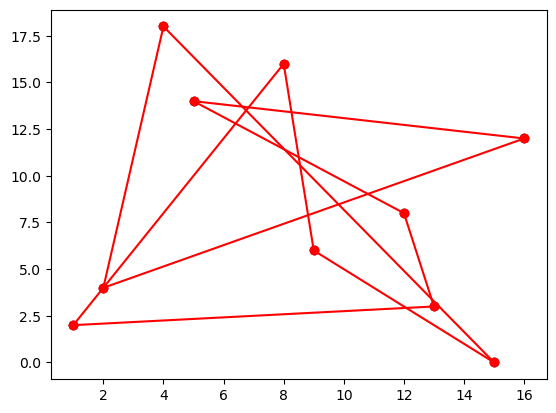

In [117]:
plot_route(points, start_route)

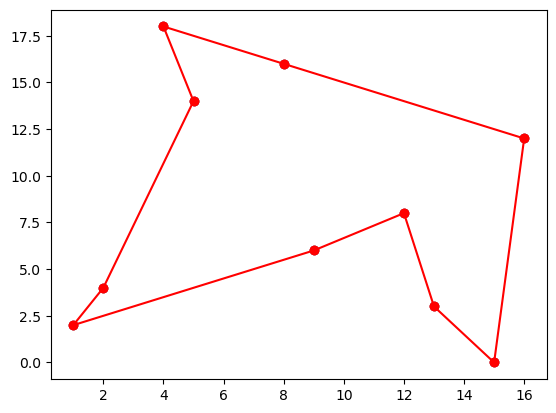

In [118]:
plot_route(points, res)